
<div style="background-color:#e6f2ff; padding:20px; border-radius:10px;">
<img style="float:left; margin-right:20px;" src='Figures/alinco.png' width="120"/>
<h1 style="color:#000047;">Actividad 3: Clasificación con una Red Neuronal Profunda con TensorFlow y Pytorch</h1>
<br style="clear:both"/>
</div>

<div style="border-left:4px solid #000047; padding:10px; margin-top:10px; background:#f5f5f5;">
<b>Objetivo:</b> Construir, entrenar y evaluar un MLP profundo en TensorFlow y Pytorch sobre un conjunto de datos real, aplicando las técnicas vistas (regularización, optimizadores, curvas de aprendizaje).
</div>


### Instrucciones

Trabajaremos con el dataset de imágenes **CIFAR-10**: 60 000 imágenes a color de $32\times32$ píxeles (50 000 de entrenamiento y 10 000 de prueba) repartidas en **10 clases** (avión, automóvil, pájaro, gato, ciervo, perro, rana, caballo, barco, camión). Está disponible de forma nativa tanto en TensorFlow (`keras.datasets.cifar10`) como en PyTorch (`torchvision.datasets.CIFAR10`).

1. **Carga y explora** el dataset: normaliza los píxeles a $[0, 1]$, **aplana** cada imagen a un vector de $32\times32\times3 = 3072$ valores (para el MLP) y **visualiza** algunos ejemplos con su clase.
2. Divide en train/validación y usa el conjunto de prueba oficial.
3. Construye un **MLP profundo con Tensorflow** (**Modelo 1**): al menos 3 capas ocultas, con `BatchNormalization`, `Dropout` y optimizador **Adam**. Define la entrada con `keras.Input(shape=(3072,))`. Entrena y reporta la precisión en test.
4. Construye el **mismo MLP con PyTorch** (**Modelo 2**): entrena con **AdamW** y un **scheduler** de tu elección (p. ej. `StepLR` o `CosineAnnealingLR`).
5. Grafica las **curvas de aprendizaje** (pérdida y precisión) de ambos modelos y reporta la **precisión en test**.
6. Muestra la **matriz de confusión** e identifica qué clases se confunden más.
7. **Compara** ambas implementaciones y anota tus conclusiones.

> un MLP sobre imágenes a color suele alcanzar ~45–55 % de precisión en CIFAR-10. Es un buen punto de partida para motivar el uso de **redes convolucionales (CNN)** más adelante.


### 0. Carga y exploración del dataset (CIFAR-10)

Esta parte ya está resuelta: carga el dataset, lo normaliza, lo aplana y muestra algunos ejemplos. Reutilizarás estas variables (`X_train`, `y_train`, `X_test`, `y_test`) en ambos modelos.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 276s 2us/step
Entrenamiento: (50000, 3072) | Prueba: (10000, 3072)
Clases: [0 1 2 3 4 5 6 7 8 9]


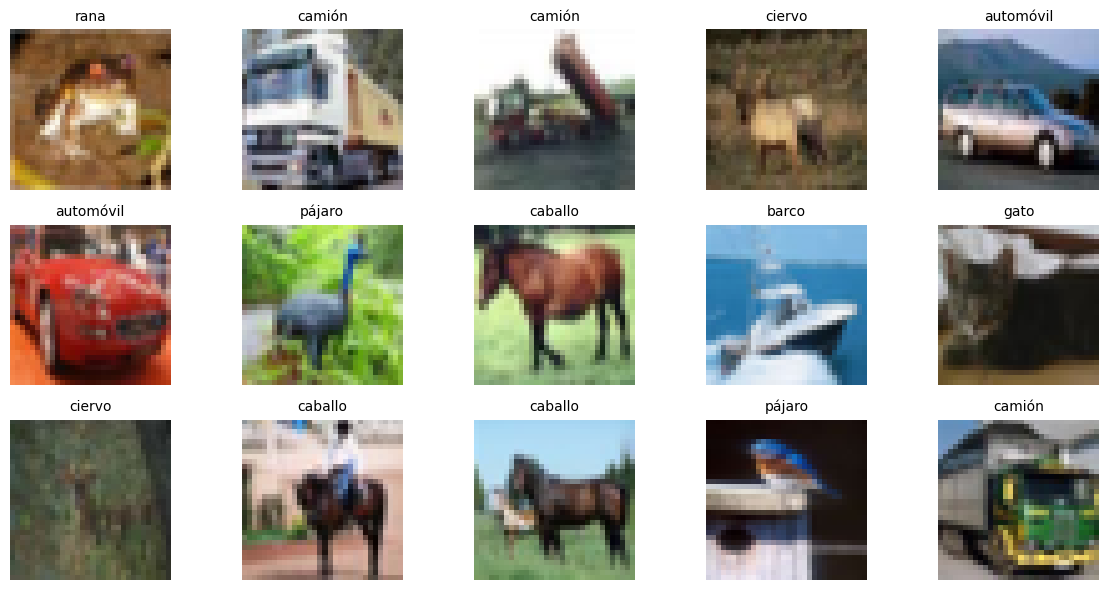

In [2]:
import os

# Evita el conflicto de múltiples runtimes OpenMP (MKL + libgomp) en Windows
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

# Nombres de las 10 clases de CIFAR-10
class_names = ['avión', 'automóvil', 'pájaro', 'gato', 'ciervo',
               'perro', 'rana', 'caballo', 'barco', 'camión']

# Cargar el dataset (imágenes 32x32x3, etiquetas 0-9)
(X_train_img, y_train), (X_test_img, y_test) = cifar10.load_data()
y_train, y_test = y_train.ravel(), y_test.ravel()   # de (N,1) a (N,)

# Normalizar a [0,1] y aplanar a vectores de 3072 (para el MLP)
X_train = (X_train_img / 255.0).reshape(-1, 32 * 32 * 3).astype('float32')
X_test  = (X_test_img  / 255.0).reshape(-1, 32 * 32 * 3).astype('float32')

print('Entrenamiento:', X_train.shape, '| Prueba:', X_test.shape)
print('Clases:', np.unique(y_train))

# Visualizar 15 imágenes con su clase
plt.figure(figsize=(12, 6))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_train_img[i])          # imagen original a color
    plt.title(class_names[y_train[i]], fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

### 1. Modelo con TensorFlow

In [24]:
import tensorflow as tf

# TODO 1: construye un MLP profundo con la API Sequential
#   - keras.Input(shape=(3072,))
#   - >= 3 capas Dense ocultas (p. ej. 512, 256, 128) con activación 'relu'
#   - usa BatchNormalization y Dropout entre capas
#   - capa de salida Dense(10, activation='softmax')

model_tf = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(3072,)),
    tf.keras.layers.Dense(units=512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=10, activation='softmax')

])

In [25]:
model_tf.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,742,474 (6.65 MB)

 Trainable params: 1,740,682 (6.64 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [26]:
# TODO 2: compila con optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']
model_tf.compile(optimizer='adam', loss= 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [27]:
# TODO 3: entrena guardando el history (usa validation_split=0.1 y varias épocas)
history_tf = model_tf.fit(X_train, y_train, batch_size = 3072, epochs = 10, verbose = 1, validation_split= 0.1)

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 633ms/step - accuracy: 0.1925 - loss: 2.8762 - val_accuracy: 0.1144 - val_loss: 7.4761
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 587ms/step - accuracy: 0.2393 - loss: 2.4408 - val_accuracy: 0.1186 - val_loss: 7.0743
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 515ms/step - accuracy: 0.2626 - loss: 2.2522 - val_accuracy: 0.1782 - val_loss: 4.0658
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 599ms/step - accuracy: 0.2813 - loss: 2.1236 - val_accuracy: 0.2140 - val_loss: 3.0512
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 569ms/step - accuracy: 0.2992 - loss: 2.0296 - val_accuracy: 0.3010 - val_loss: 2.1918
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 514ms/step - accuracy: 0.3190 - loss: 1.9515 - val_accuracy: 0.3362 - val_loss: 1.9110
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 623ms/step - accuracy: 0.3276 - loss: 1.8993 - val_accuracy: 0.3842 - val_loss: 1.7367
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 600ms/step - accuracy: 0.3460 - loss: 1.8468 - val_accuracy: 

In [29]:
# TODO 4: evalúa en test e imprime la precisión
test_loss, test_accuracy = model_tf.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3923 - loss: 1.6991


In [32]:
print(f"Accuracy de entrenamiento: {history_tf.history['accuracy'][-1] * 100:.2f}%")
print(f"Accuracy de validación: {history_tf.history['val_accuracy'][-1] * 100:.2f}%")
print(f"Perdida de validación: {history_tf.history['val_loss'][-1]:.2f}")
print(f"Precisión en test: {test_accuracy*100:.2f}")
print(f"Perdida test: {test_loss:.2f}")

Accuracy de entrenamiento: 36.54%
Accuracy de validación: 38.10%
Perdida de validación: 1.73
Precisión en test: 39.23
Perdida test: 1.25


### 2. Modelo con Pytorch

In [9]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Reutilizamos los MISMOS datos de CIFAR-10 ya normalizados y aplanados (3072)
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

# TODO 1: separa un 10% del entrenamiento para validación
train_size = int(0.9 * len(X_train_t))
val_size = len(X_train_t) - train_size
train_ds = TensorDataset(X_train_t[:-val_size], y_train_t[:-val_size])
val_ds = TensorDataset(X_train_t[-val_size:], y_train_t[-val_size:])
test_ds = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)


# TODO 2: crea TensorDataset y DataLoader (train/val/test) con batch_size=128
print('Tensores listos:', X_train_t.shape, X_test_t.shape, '| Dispositivo:', device)

Tensores listos: torch.Size([50000, 3072]) torch.Size([10000, 3072]) | Dispositivo: cpu


In [19]:
# TODO 3: define tu MLP profundo (>= 3 capas ocultas, BatchNorm, Dropout)
#   Entrada: 3072 features -> salida: 10 clases (logits, sin softmax)
class MiMLP(nn.Module):
    def __init__(self, num_features=3072, num_classes=10):
        super().__init__()
        self.fc1 = nn.Linear(num_features, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()
        self.bn1 = nn.BatchNorm1d(512)
        self.bn2 = nn.BatchNorm1d(256)
        self.bn3 = nn.BatchNorm1d(128)
        self.dropout = nn.Dropout(0.3)
        pass

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc4(x)
        return x
        # ... completa aquí (nn.Linear, nn.BatchNorm1d, nn.ReLU, nn.Dropout) ...
        pass

In [20]:
net = MiMLP()
print(net)

MiMLP(
  (fc1): Linear(in_features=3072, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (fc4): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [21]:
# TODO 4: bucle de entrenamiento con AdamW + scheduler
model = MiMLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

def run_epoch(loader, entrenar=True):
    model.train() if entrenar else model.eval()
    loss_tot, aciertos, total = 0.0, 0, 0
    contexto = torch.enable_grad() if entrenar else torch.no_grad()
    with contexto:
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            if entrenar:
                optimizer.zero_grad()        # 1. limpiar gradientes
            logits = model(xb)            # 2. forward
            loss = criterion(logits, yb)     # 3. pérdida
            if entrenar:
                loss.backward()              # 4. backward
                optimizer.step()             # 5. actualizar pesos
            loss_tot += loss.item() * xb.size(0)
            aciertos += (logits.argmax(1) == yb).sum().item()
            total += yb.size(0)
    return loss_tot / total, aciertos / total


EPOCHS = 10
hist_pt = {'loss': [], 'val_loss': [], 'acc': [], 'val_acc': []}
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, entrenar=True)
    va_loss, va_acc = run_epoch(val_loader, entrenar=False)
    hist_pt['loss'].append(tr_loss); hist_pt['val_loss'].append(va_loss)
    hist_pt['acc'].append(tr_acc);   hist_pt['val_acc'].append(va_acc)
    print(f"Época {epoch:2d}/{EPOCHS} | loss={tr_loss:.4f} acc={tr_acc:.4f} | "
          f"val_loss={va_loss:.4f} val_acc={va_acc:.4f}")
    scheduler.step()

Época  1/10 | loss=1.7539 acc=0.3705 | val_loss=1.8115 val_acc=0.3684
Época  2/10 | loss=1.5611 acc=0.4418 | val_loss=1.4986 val_acc=0.4728
Época  3/10 | loss=1.4825 acc=0.4718 | val_loss=1.4412 val_acc=0.4864
Época  4/10 | loss=1.4266 acc=0.4919 | val_loss=1.3869 val_acc=0.4924
Época  5/10 | loss=1.3799 acc=0.5085 | val_loss=1.3633 val_acc=0.5166
Época  6/10 | loss=1.2890 acc=0.5411 | val_loss=1.2529 val_acc=0.5574
Época  7/10 | loss=1.2614 acc=0.5564 | val_loss=1.2393 val_acc=0.5616
Época  8/10 | loss=1.2430 acc=0.5606 | val_loss=1.2374 val_acc=0.5656
Época  9/10 | loss=1.2248 acc=0.5668 | val_loss=1.2288 val_acc=0.5670
Época 10/10 | loss=1.2129 acc=0.5702 | val_loss=1.2237 val_acc=0.5700


In [31]:
test_loss, test_acc = run_epoch(test_loader, entrenar=False)

In [33]:
print(f"Accuracy de entrenamiento: {hist_pt['acc'][-1] * 100:.2f}%")
print(f"Accuracy de validación: {hist_pt['val_acc'][-1] * 100:.2f}%")
print(f"Accuracy de test: {test_acc * 100:.2f}%")

Accuracy de entrenamiento: 57.02%
Accuracy de validación: 57.00%
Accuracy de test: 55.33%


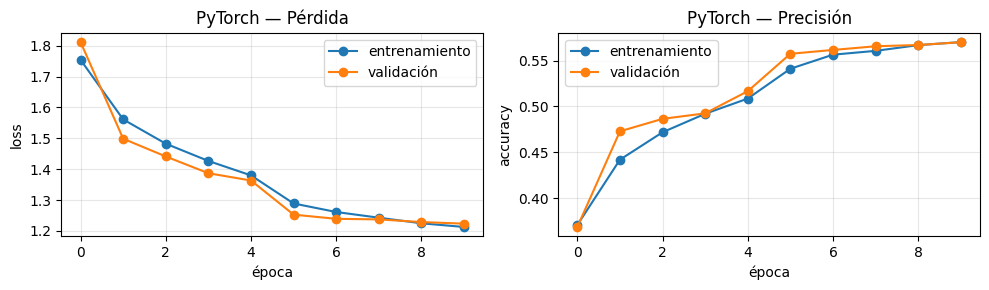

In [35]:
# TODO 5: curvas de aprendizaje y precisión en test
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

ax1.plot(hist_pt['loss'], marker='o', label='entrenamiento')
ax1.plot(hist_pt['val_loss'], marker='o', label='validación')
ax1.set_title('PyTorch — Pérdida'); ax1.set_xlabel('época'); ax1.set_ylabel('loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(hist_pt['acc'], marker='o', label='entrenamiento')
ax2.plot(hist_pt['val_acc'], marker='o', label='validación')
ax2.set_title('PyTorch — Precisión'); ax2.set_xlabel('época'); ax2.set_ylabel('accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

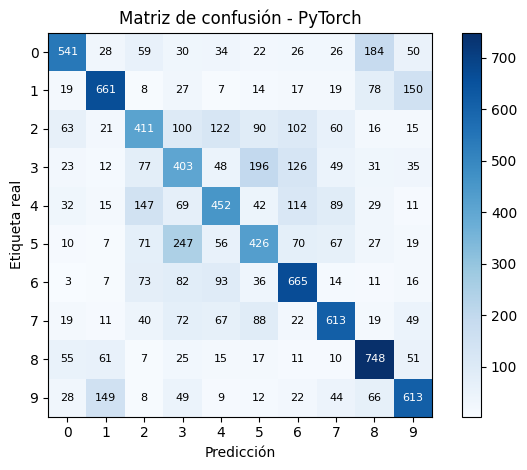

In [46]:
# TODO 6: matriz de confusión
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
model.eval()
y_pred = []
y_true = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = model(images)
        predicciones = logits.argmax(1).cpu().numpy()
        y_pred.extend(predicciones)
        y_true.extend(labels.numpy())
        pass

cm = confusion_matrix(y_true, y_pred)

plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(10)); plt.yticks(range(10))
plt.xlabel('Predicción'); plt.ylabel('Etiqueta real')
plt.title('Matriz de confusión - PyTorch')
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                 color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=8)
plt.tight_layout()
plt.show()

In [45]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.682     0.541     0.603      1000
           1      0.680     0.661     0.670      1000
           2      0.456     0.411     0.432      1000
           3      0.365     0.403     0.383      1000
           4      0.501     0.452     0.475      1000
           5      0.452     0.426     0.438      1000
           6      0.566     0.665     0.611      1000
           7      0.619     0.613     0.616      1000
           8      0.619     0.748     0.677      1000
           9      0.608     0.613     0.610      1000

    accuracy                          0.553     10000
   macro avg      0.555     0.553     0.552     10000
weighted avg      0.555     0.553     0.552     10000



###Comparación de Modelos
|Modelo            |Entrenamiento     |Validación        |Test         |
|------------------|------------------|------------------|-------------|
|TensorFlow        |36.54%            |38.10%            |39.23%       |
|PyTorch           |57.02%            |57.00%            |55.33%       |

Se observa en la tabla como la precisión de ambos modelos en entrenamiento y validación lo supero PyTorch, ya que la diferencia es mínima 0.02%.
El Modelo PyTorch,obtuvo mejor dsempeño con el 55.33% de precisión en test en comparación el 39.23% que obtuvo TensorFlow.